In [2]:
import dask
dask.config.set({'dataframe.query-planning': False})

In [3]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import beta as beta_dist

In [1]:
import scarf
scarf .__version__

'0.32.3'

In [12]:
## repeat this for all 7 h5ad files
reader = scarf.H5adReader(
    h5ad_fn="STH.h5ad",
    cell_ids_key="CellID",          
    feature_ids_key="_index",        
    feature_name_key="feature_name", 
    matrix_key="X",                     
)

writer = scarf.H5adToZarr(
    reader,
    zarr_loc='STH.zarr',
    chunk_size=(2000,1000)
)
writer.dump()



INFO: No value provided for assay names. Will use default value: 'RNA'


Reading attributes from group obs:   0%|                                                                      …

Reading attributes from group obsm:   0%|                                                                     …

Reading attributes from group var:   0%|                                                                      …

  0%|                                                                                                         …

In [5]:
ds_GPe = scarf.DataStore(
    'GPe.zarr', 
    nthreads=4
)
ds_GPi = scarf.DataStore(
    'GPi.zarr', 
    nthreads=4
)
ds_CaB = scarf.DataStore(
    'CaB.zarr', 
    nthreads=4
)

ds_NAC = scarf.DataStore(
    'NAC.zarr', 
    nthreads=4
)

ds_PU = scarf.DataStore(
    'PU.zarr', 
    nthreads=4
)

ds_SN = scarf.DataStore(
    'SN.zarr', 
    nthreads=4
)

ds_STH = scarf.DataStore(
    'STH.zarr', 
    nthreads=4
)


(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

...

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

In [6]:
scarf.AssayMerge(
    zarr_path = '/Users/saatvikviniak/Desktop/Lab work/sc-RNA atlas/merged.zarr',
    assays = [ds_GPe.RNA, ds_GPi.RNA, ds_CaB.RNA, ds_NAC.RNA, ds_PU.RNA, ds_SN.RNA, ds_STH.RNA],
    names = ['GPe', 'GPi', 'CaB', 'NAC', 'PU', 'SN', 'STH',],
    merge_assay_name='RNA',
    overwrite=True
).dump()

Writing data from assay 1/7 to merged file:   0%|                                                             …

Writing data from assay 2/7 to merged file:   0%|                                                             …

Writing data from assay 3/7 to merged file:   0%|                                                             …

Writing data from assay 4/7 to merged file:   0%|                                                             …

Writing data from assay 5/7 to merged file:   0%|                                                             …

Writing data from assay 6/7 to merged file:   0%|                                                             …

Writing data from assay 7/7 to merged file:   0%|                                                             …

# QC + Preprocessing here

## When running qc, if need to reset the dataset, to modify settings like min_features_per_cell, run the following commented commands, then load the dataset again
ds.cells.insert('I', np.ones(ds.cells.N, dtype=bool), overwrite=True, force=True)

ds.RNA.feats.insert('I', np.ones(ds.RNA.feats.N, dtype=bool), overwrite=True, force=True)

In [4]:
ds = scarf.DataStore(
    'merged.zarr',
    nthreads=6,
    min_features_per_cell=800,  # filtrs out cells expressing 800 or less genes
    min_cells_per_feature=100   # filters out genes expressed in less than 100 cells
)

In [8]:
## Keep track of cells from different samples by adding a column known as sample id, easily associate what cell is from dataset
ds.cells.insert(
    column_name='sample_id',
    values=[x.split('__')[0] for x in ds.cells.fetch_all('ids')],
    overwrite=True
)

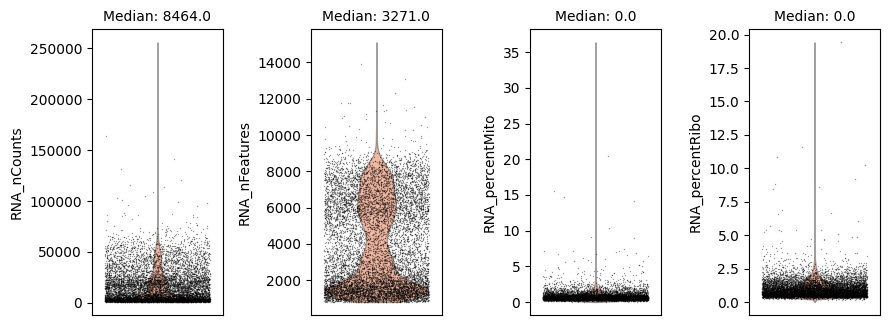

In [9]:
ds.plot_cells_dists(cell_key='I', color='coral')

In [ ]:
## 255905 cells pre-qc
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'],
    highs=[60000, 9000, 3.0, 2.4],  
    lows=[1000,  500,  0.0, 0.0]
)

## 242634 cells post QC

INFO: 5311 cells flagged for filtering out using attribute RNA_nCounts
INFO: 1953 cells flagged for filtering out using attribute RNA_nFeatures
INFO: 2743 cells flagged for filtering out using attribute RNA_percentMito
INFO: 7254 cells flagged for filtering out using attribute RNA_percentRibo


In [12]:
ds

DataStore has 242634 (261691) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'orig_RNA_nCounts', 'orig_RNA_nFeatures', 'orig_RNA_percentMito', 
            'orig_RNA_percentRibo', 'orig_X_UMAP1', 'orig_X_UMAP2', 'orig_X_tSNE1', 'orig_X_tSNE2', 
            'orig_cell_cycle_score', 'orig_fraction_mitochondrial', 'orig_fraction_unspliced', 'orig_is_primary_data', 'orig_observation_joinid', 
            'orig_total_UMIs', 'orig_total_genes', 'sample_id'
   RNA assay has 31864 (58232) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

In [13]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,nCells
0,True,ENSG00000271098,IMMP1LP3,261281,410
1,True,ENSG00000251026,NIHCOLE,258979,2712
2,True,ENSG00000129451,KLK10,260495,1196
3,True,ENSG00000163568,AIM2,256514,5177
4,True,ENSG00000253327,RAD21-AS1,260780,911


INFO: Calculating summary statistics


(RNA) Computing nCells:   0%|                                                                                 …

(RNA) Computing normed_tot:   0%|                                                                             …

(RNA) Computing sigmas:   0%|                                                                                 …

INFO: Calculating HVGs
INFO: 3990 genes marked as HVGs


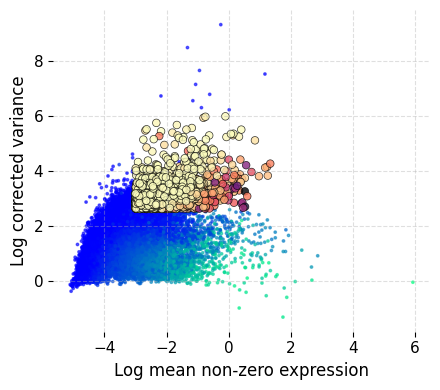

In [14]:
ds.mark_hvgs(
    min_cells=100, # Gene should have non-zero expression values in at least 100 cells
    top_n=4000,
    min_mean=-3, # come back and fully refine the following 3 parameters
    max_mean=2,
    max_var=6
)

### Graph Creation ~ Performing batch correction using harmony here

In [40]:
ds.make_graph(
    feat_key='hvgs',
    k=30, # starting wit a total of 35 nearest neighbors
    dims=40,
    n_centroids=2400, # For centroids, calculating roughly using ~ Total cell count / 100. Have a value of 1+ (>1) for every 100 cells
    show_elbow_plot = True,
    harmonize = True,
    batch_columns = ['sample_id']
)

INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 40 dims
INFO: Using existing harmonized data with 40 dims
INFO: Using existing ANN index
INFO: Cluster number reduced to batch size of 1000


Fitting kmeans:   0%|                                                                                         …

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/p

Estimating seed partitions:   0%|                                                                             …

INFO: KNN graph already exists will not recompute.


In [22]:
ds.run_umap(
    n_epochs=300, # Starting with default
    spread=4, #For purely visualization purposes
    min_dist=1, #For purely visualization purposes
    random_seed=2009
    )

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

Training UMAP:   0%|                                                                                          …

	completed  0  /  300 epochs
	completed  30  /  300 epochs
	completed  60  /  300 epochs
	completed  90  /  300 epochs
	completed  120  /  300 epochs
	completed  150  /  300 epochs
	completed  180  /  300 epochs
	completed  210  /  300 epochs
	completed  240  /  300 epochs
	completed  270  /  300 epochs


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/metadata.py:334: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [37]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_UMAP3,RNA_leiden_cluster,RNA_nCounts,RNA_nFeatures,RNA_percentMito,...,orig_X_tSNE1,orig_X_tSNE2,orig_cell_cycle_score,orig_fraction_mitochondrial,orig_fraction_unspliced,orig_is_primary_data,orig_observation_joinid,orig_total_UMIs,orig_total_genes,sample_id
0,True,GPi__10X357_1:GCATTAGGTTGGGTAG,10X357_1:GCATTAGGTTGGGTAG,26.710371,1.797275,0.590325,4,2408.0,1324.0,0.581395,...,1.189798,-32.696562,0.001650,0.001650,0.638201,True,v3B6Zv6z_d,2424.0,1335.0,GPi
1,True,GPi__10X385_3:TCGGGCAGTCAGGCAA,10X385_3:TCGGGCAGTCAGGCAA,29.685419,-0.357713,-2.689943,4,2373.0,1323.0,1.348504,...,1.087873,-36.468209,0.000419,0.000839,0.571728,True,xTIYJ0;=HN,2384.0,1332.0,GPi
2,True,GPi__10X389_7:CATGGATTCAACTGAC,10X389_7:CATGGATTCAACTGAC,30.010597,11.234342,-2.188437,4,2123.0,1317.0,0.659444,...,32.337446,-27.800528,0.000468,0.000000,0.644528,True,1Z4_+ehJ<g,2138.0,1329.0,GPi
3,True,GPi__10X385_3:AGCTCAAGTCCAATCA,10X385_3:AGCTCAAGTCCAATCA,29.433830,2.164363,-2.515555,4,3080.0,1512.0,0.584416,...,10.872583,-32.420473,0.000323,0.001613,0.637625,True,niqw9wf)Xp,3099.0,1524.0,GPi
4,True,GPi__10X389_7:ATGGGTTAGCTGTGCC,10X389_7:ATGGGTTAGCTGTGCC,29.189550,10.381250,-2.628001,4,1257.0,872.0,0.954654,...,33.715825,-32.900576,0.000000,0.001585,0.578447,True,e@s7)@#6s%,1262.0,877.0,GPi


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


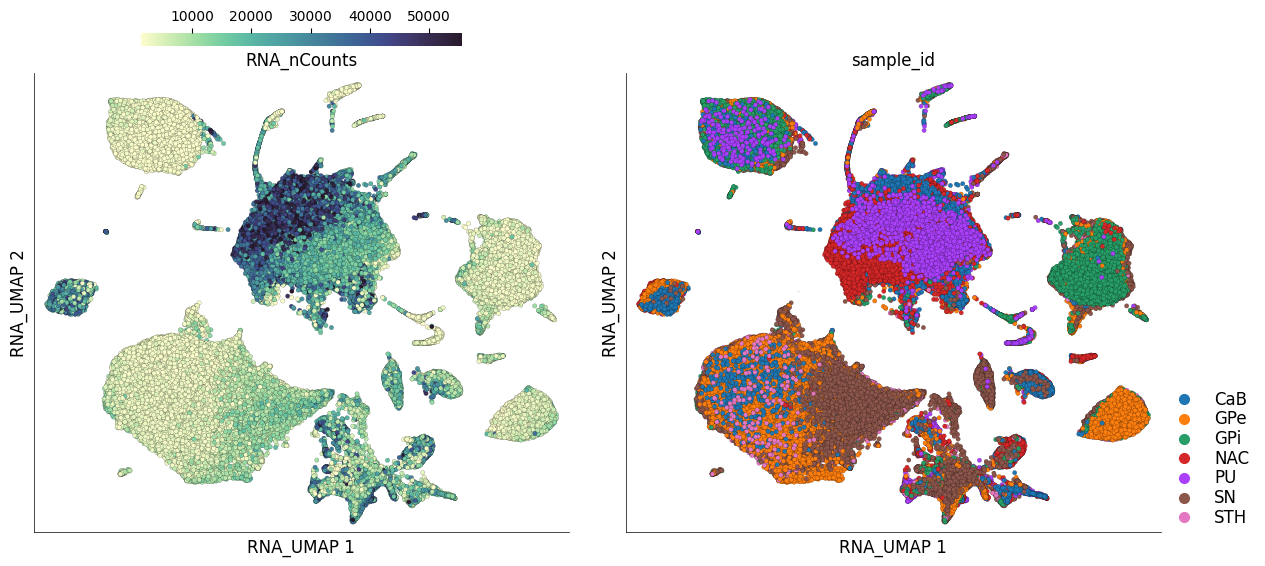

In [23]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by=['RNA_nCounts','sample_id'],
    legend_ondata=False
)

In [24]:
ds.run_leiden_clustering(resolution=.9) 

In [7]:
 # output the leiden cluster info into a pds df
leiden_clusters = ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)

In [8]:
ds.run_clustering(n_clusters=leiden_clusters.nunique().iloc[0]) ## make it so that the total # of RNA clusters match the # of leiden clusters

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [10]:
ds.run_marker_search(
    group_key='RNA_cluster',
    gene_batch_size=300, # of genes to be loaded into memory per run
    
)

Finding markers:   0%|                                                                                        …

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


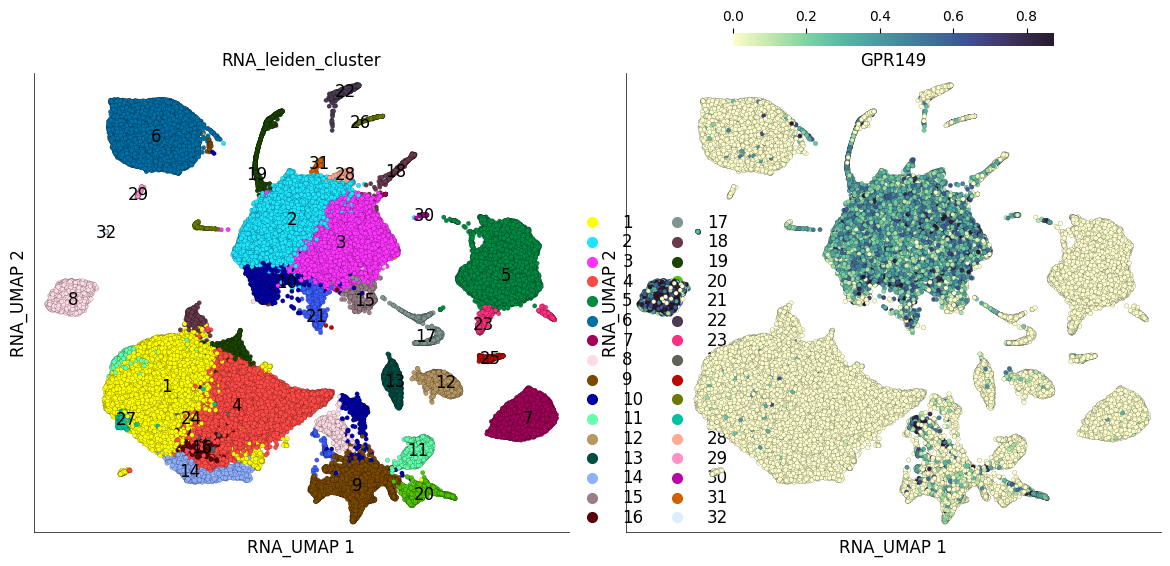

In [11]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by=['RNA_leiden_cluster', 'GPR149']
)
#savename=None, save_dpi=300bb

## to back to the current plot, set epochs = 300

In [ ]:
from trinarizer_scarf import build_trinarization_matrix
results = build_trinarization_matrix(ds)


In [8]:
results[8] # do results[some number] for a specific page in the dcit

{'IMMP1LP3': 'off',
 'NIHCOLE': 'off',
 'KLK10': 'off',
 'AIM2': 'off',
 'RAD21-AS1': 'off',
 'FER1L6': 'off',
 'ENSG00000220256': 'off',
 'ENSG00000287502': 'off',
 'MYOZ1': 'off',
 'ENSG00000273295': 'off',
 'ENSG00000231069': 'off',
 'ENSG00000287548': 'off',
 'ENSG00000250267': 'off',
 'NRTN': 'off',
 'XIRP2': 'off',
 'HLX-AS1': 'off',
 'BSPH1': 'off',
 'KRT39': 'off',
 'LINC00896': 'off',
 'LINC00492': 'off',
 'MROCKI': 'off',
 'EPSTI1': 'off',
 'EXPH5': 'on',
 'ENG': 'off',
 'LINC02267': 'off',
 'GGTA1': 'off',
 'FAM111A-DT': 'off',
 'H2AC17': 'off',
 'SAMSN1': 'off',
 'CYBA': 'off',
 'GJD2': 'off',
 'PTH1R': 'off',
 'BHLHE22': 'off',
 'LDHBP3': 'off',
 'KRT17': 'off',
 'ENSG00000262495': 'off',
 'ENSG00000272864': 'off',
 'PVALB': 'off',
 'AQP3': 'off',
 'CLCNKB': 'off',
 'EN2': 'off',
 'ENSG00000272717': 'off',
 'LINC02058': 'off',
 'C1R': 'off',
 'SERTM1': 'off',
 'C1QL2': 'off',
 'ENSG00000286285': 'off',
 'NRP2': 'off',
 'KDR': 'off',
 'SOX5-AS1': 'off',
 'ENSG00000285568': 

In [13]:
gene_status = results[2]['GPR149']
print(gene_status)

on


# Perform Autoannotation

In [ ]:
from auto_annotator_scarf import annotate_cluster, load_rules
path = "/Users/saatvikviniak/Desktop/Lab work/sc-RNA atlas/auto-annotation-ah/Human_adult"
rules = load_rules(path)



In [15]:
annotations = {}

for cluster, gene_calls in results.items():
    present_genes = {
        gene for gene, call in gene_calls.items() if call == "on"
    }
    absent_genes = {
        gene for gene, call in gene_calls.items() if call == "off"
    }
    annotations[cluster] = annotate_cluster(
        present_genes, absent_genes, rules
    )

In [16]:
annotations
## To determine the true subtype of cluster 32, what we can do is count the amount of cells in the cluster since it appears to be purely putamen, 
# and cross reference it against the existing cluster annotations and see

{-1: ['NEUR'],
 1: ['OLIGO'],
 2: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2'],
 3: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2'],
 4: ['OLIGO'],
 5: ['ASTRO'],
 6: ['MGL'],
 7: ['OPC'],
 8: ['MSN-D1', 'MSN-ECC', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2'],
 9: ['NEUR', 'NT-GABA', 'NT-GABA', 'NT-VGLUT2'],
 10: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA'],
 11: ['NEUR', 'NT-GABA', 'NT-GABA'],
 12: ['NEUR', 'NT-GABA', 'NT-GABA'],
 13: ['NEUR', 'NT-GABA', 'NT-GABA'],
 14: ['OLIGO'],
 15: ['NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2'],
 16: ['OLIGO'],
 17: [],
 18: ['OLIGO', 'HDC'],
 19: ['NEUR', 'OLIGO'],
 20: ['INT-VIP', 'NEUR', 'NT-GABA', 'NT-GABA', 'INT-LAMP5'],
 21: ['NT-VGLUT1', 'NEUR', 'DG-GRAN'],
 22: ['MAC'],
 23: ['ASTRO'],
 24: ['OLIGO'],
 25: ['OLIGO', 'EPEN'],
 26: ['NEUR', 'ENDO', 'CAP'],
 27: ['OLIGO'],
 28: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2'],
 29: ['MGL'],
 30: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2'],
 31: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MS

In [17]:
for cluster, gene_calls in results.items():
    if gene_calls.get('GPR149') == 'on':
        print(f"Cluster {cluster} expresses GPR149 — annotated as: {annotations[cluster]}")

Cluster -1 expresses GPR149 — annotated as: ['NEUR']
Cluster 2 expresses GPR149 — annotated as: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2']
Cluster 3 expresses GPR149 — annotated as: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2']
Cluster 8 expresses GPR149 — annotated as: ['MSN-D1', 'MSN-ECC', 'NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2']
Cluster 9 expresses GPR149 — annotated as: ['NEUR', 'NT-GABA', 'NT-GABA', 'NT-VGLUT2']
Cluster 10 expresses GPR149 — annotated as: ['MSN-D1', 'NEUR', 'NT-GABA', 'NT-GABA']
Cluster 12 expresses GPR149 — annotated as: ['NEUR', 'NT-GABA', 'NT-GABA']
Cluster 15 expresses GPR149 — annotated as: ['NEUR', 'NT-GABA', 'NT-GABA', 'MSN-D2']
Cluster 19 expresses GPR149 — annotated as: ['NEUR', 'OLIGO']
Cluster 20 expresses GPR149 — annotated as: ['INT-VIP', 'NEUR', 'NT-GABA', 'NT-GABA', 'INT-LAMP5']
Cluster 21 expresses GPR149 — annotated as: ['NT-VGLUT1', 'NEUR', 'DG-GRAN']
Cluster 26 expresses GPR149 — annotated as: ['NEUR', 'ENDO', 'CAP']
Cluster 28 expre

In [ ]:
updated_annotations = {
-1: ['NEUR'],
 1: ['OLIGO'],
 2: ['MSN-D2'], ### going for this, prefering MSN-D2 just due to the fact of DRD2 BEING slightly more prominent than FOXP2
 3: ['MSN-D1', 'NT-GABA', 'MSN-D2'],
 4: ['OLIGO'],
 5: ['ASTRO'],
 6: ['MGL'],
 7: ['OPC'],
 8: ['MSN-D1', 'MSN-ECC', 'NT-GABA', 'MSN-D2'],
 9: ['NT-GABA'], ## GABA over VGLUT 2 due to how little SLC17A6 is expressed
 10: ['MSN-D1', 'NT-GABA'],
 11: ['NT-GABA'],
 12: ['NT-GABA'],
 13: ['NT-GABA'],
 14: ['OLIGO'],
 15: ['NT-GABA', 'MSN-D2'],
 16: ['OLIGO'],
 17: [],
 18: ['OLIGO', 'HDC'],
 19: ['NEUR', 'OLIGO'],
 20: ['INT-VIP', 'NT-GABA', 'INT-LAMP5'],
 21: ['NT-VGLUT1', 'NEUR', 'DG-GRAN'],
 22: ['MAC'],
 23: ['ASTRO'],
 24: ['OLIGO'],
 25: ['OLIGO', 'EPEN'],
 26: ['NEUR', 'ENDO', 'CAP'],
 27: ['OLIGO'],
 28: ['MSN-D1', 'NT-GABA', 'MSN-D2'],
 29: ['MGL'],
 30: ['MSN-D1', 'NT-GABA', 'MSN-D2'],
 31: ['MSN-D1', 'NT-GABA', 'MSN-D2'],
 32: ['NEUR']}

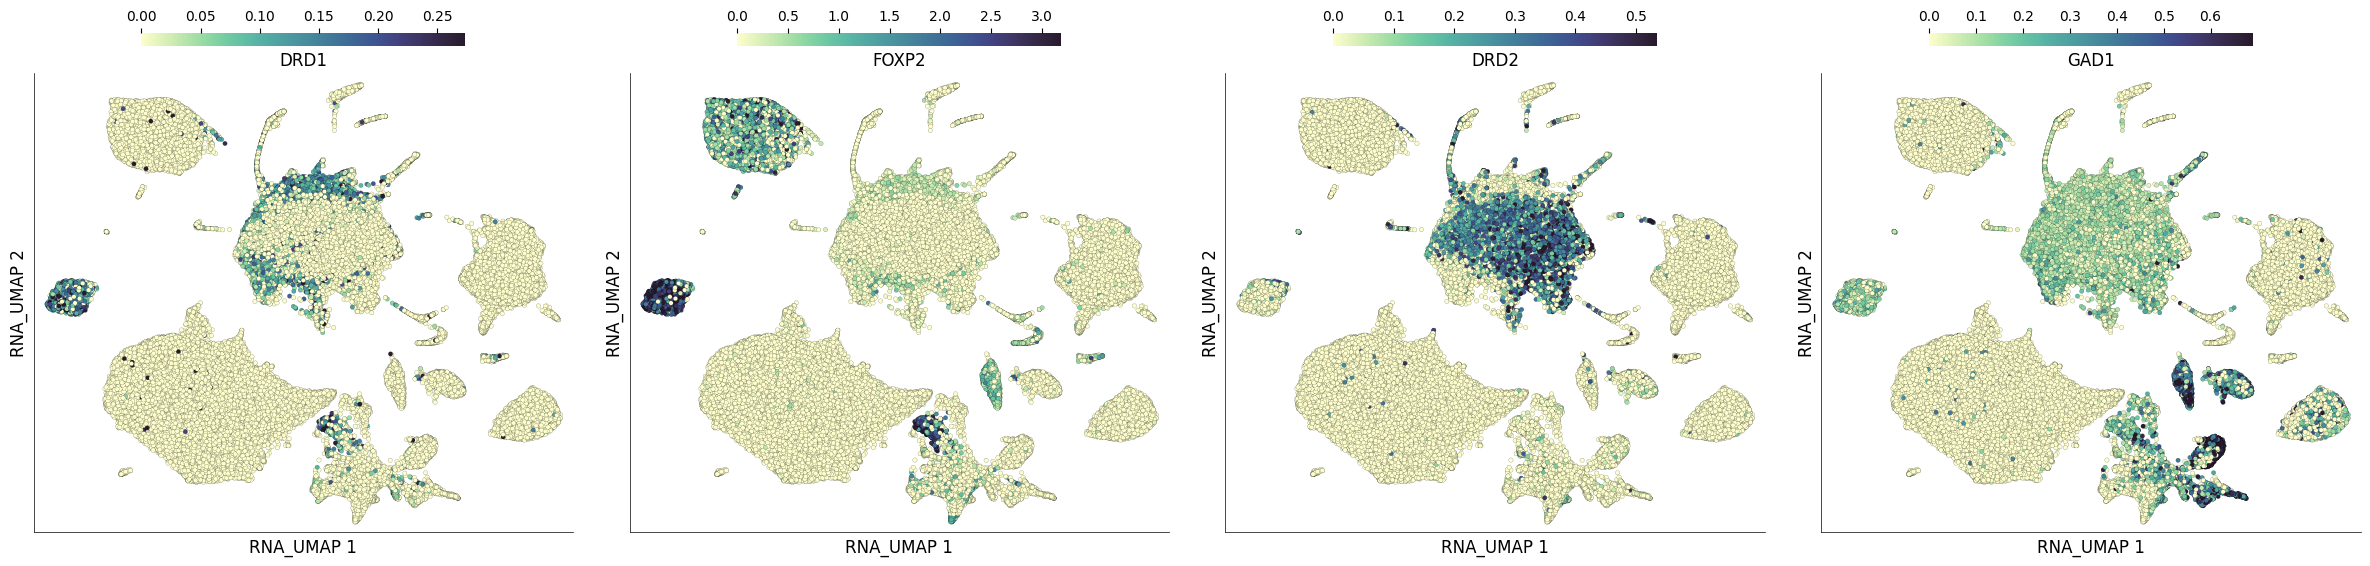

In [ ]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=['DRD1', 'FOXP2', 'DRD2', 'GAD1']
)
## DRD1 is for D1 MSN, DRD2 is for D2 MSN. When workspace restarts, on the left side of VSCODE open up the leiden cluster

In [15]:
## Reinsert our annotations

clean_annotations = {}

for key, value_list in annotations.items():
    if value_list: 
        first_item = value_list[-1]
        clean_annotations[key] = first_item
    else:
        clean_annotations[key] = "Requires Manual Annotation"  # Default label for empty matches


In [16]:
cluster_ids = ds.cells.fetch_all('RNA_leiden_cluster')
cell_types = [clean_annotations.get(cluster, 'Unannotated') for cluster in cluster_ids]

In [17]:
ds.cells.insert('cell_type', cell_types, overwrite=True)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


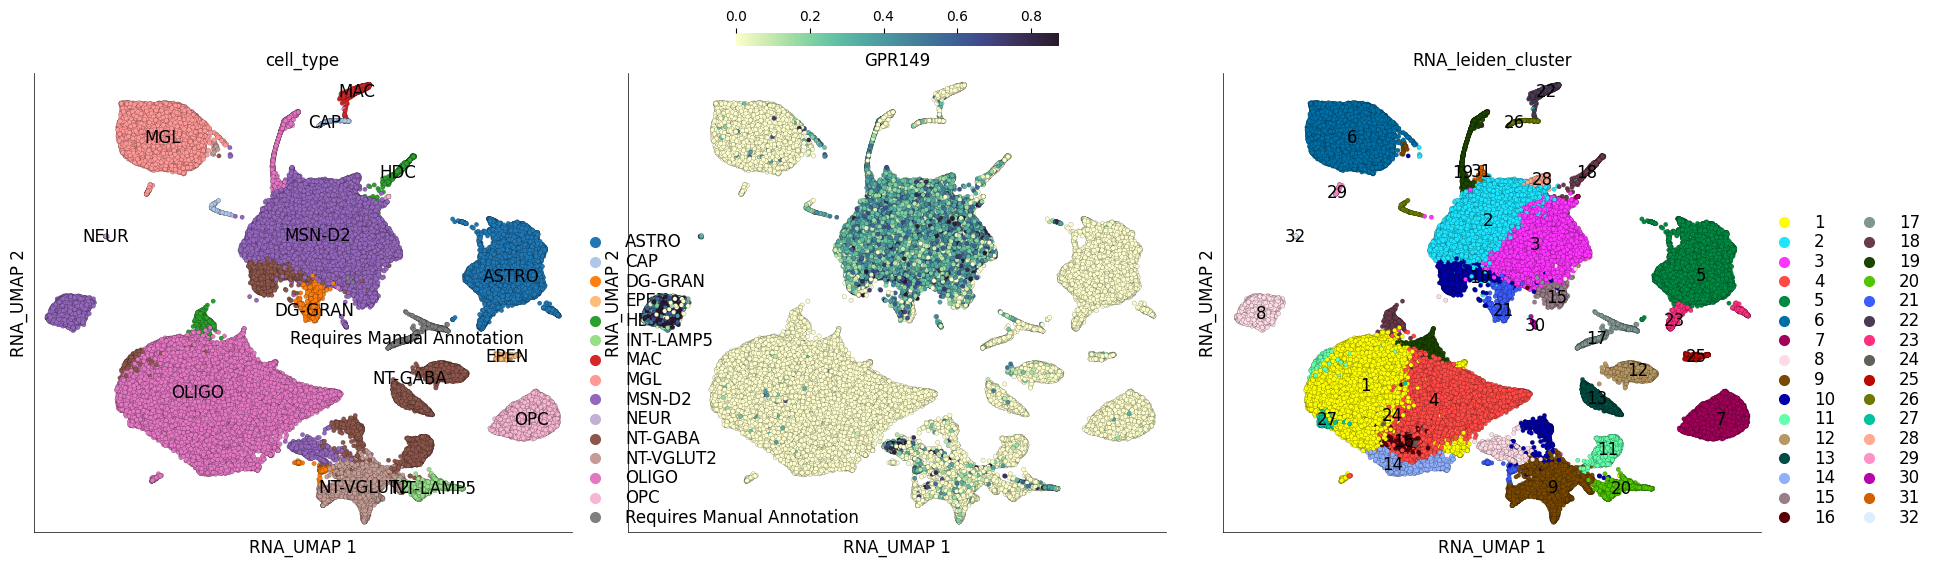

In [18]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by=['cell_type', 'GPR149', "RNA_leiden_cluster"],
)